# Implications for discharge process

This notebook use continous predictions from deep clustering to compare with esitmiated discharge process from synthetic modeling

**Content:** 
1. Load data 
2. Synthetic hydrographs modeled from rainfall data
3. Compare DEC-predicted discharge time with modeled discharge time

**Figures:**

This notebook is used to plot Figures 10 and 11 in the manuscript.

In [1]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
import obspy

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import MinuteLocator

In [2]:
datadir = './data/'

# 1. Load data
Prepare rainfall rate data and predicted labels from 2019 and 2021 data

In [3]:
# Rainfall data
# -------------- 2021 ------------------
df = pd.read_csv(datadir+'weather_data/rain_beaver_2021.csv',parse_dates=True,index_col=[1])
df = df.resample('T').mean()
df.index = df.index + pd.DateOffset(hours=4)
df['Rain Rate'] = df['Rain Rate'].interpolate()

df_sub = df[df.index.isin(pd.date_range(start='2021-06-01 00:00',
                                    end='2021-09-01 00:00',freq='T'))]
rain21 = df_sub['Rain Rate'].values*25.4

# -------------- 2019 ------------------
df = pd.read_csv(datadir+'weather_data/rain_beaver_2019.csv',parse_dates=True,index_col=[1])
df = df.resample('T').mean()
df.index = df.index + pd.DateOffset(hours=4)
df['Rain Rate'] = df['Rain Rate'].interpolate()

df_sub = df[df.index.isin(pd.date_range(start='2019-06-18 00:00',
                                    end='2019-09-01 00:00',freq='T'))]
rain19 = df_sub['Rain Rate'].values*25.4

In [4]:
# Predictions from model
y_2019 = np.load(datadir+'predictions/prediction_2019.npy')
y_2021 = np.load(datadir+'predictions/prediction_2021.npy')

## 2. Synthetic hydrograph

The SCS synthetic unit hydrograph is obtained from https://www.nohrsc.noaa.gov/technology/gis/uhg_manual.html.

In [5]:
# Unit hydrograph
q_qp = np.array([0.   , 0.03 , 0.1  , 0.19 , 0.31 , 0.47 , 0.66 , 0.82 , 0.93 ,
       0.99 , 1.   , 0.99 , 0.93 , 0.86 , 0.78 , 0.68 , 0.56 , 0.46 ,
       0.39 , 0.33 , 0.28 , 0.207, 0.147, 0.107, 0.077, 0.055, 0.04 ,
       0.029, 0.021, 0.015, 0.011, 0.005, 0.   ])
t_tp = np.array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
       1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.2, 2.4, 2.6, 2.8, 3. ,
       3.2, 3.4, 3.6, 3.8, 4. , 4.5, 5. ])

Apply scaling to unit hydrograph

In [6]:
tp = 10
qp = 484*0.0038/(tp/60)*0.0283168

t_tp_new = np.arange(0, 5*tp, 1)
interpolation_function = interp1d(tp*t_tp, q_qp, kind='slinear')
q_qp_resampled = interpolation_function(t_tp_new)
uh = q_qp_resampled*qp

Select Aug 18, 2021 to showcase modeled discharge from unit hydrograph

In [7]:
t0 = obspy.UTCDateTime('202106010000')
start = obspy.UTCDateTime('202108180700')
end = obspy.UTCDateTime('202108181200')
all_dates = pd.date_range(start='2021-08-18 07:00', end='2021-08-18 12:00', freq='T')

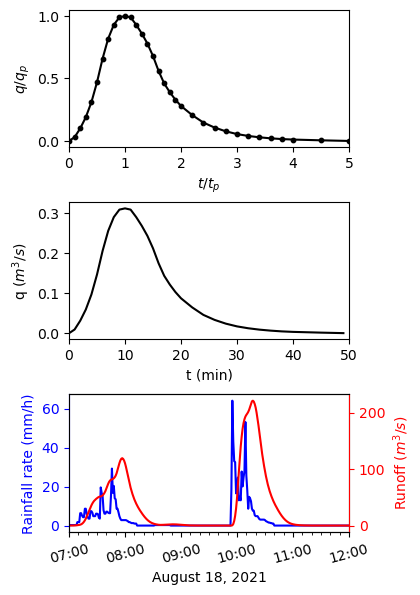

In [8]:
fig, axs = plt.subplots(nrows=3, figsize=(4, 6))
fig.subplots_adjust(left=0.15, right=0.85, top=0.97, bottom=0.1, hspace=0.4)
axs[0].plot(t_tp, q_qp, c='k')
axs[0].scatter(t_tp, q_qp, s=10, c='k')
axs[0].set_xlabel('$t/t_p$')
axs[0].set_ylabel('$q/q_p$')

axs[1].plot(t_tp_new, uh, c='k')
axs[1].set_xlabel('t (min)')
axs[1].set_ylabel('q $(m^3/s)$')

rain_example = np.copy(rain21[int((start-t0)/60):int((end-t0)/60)+1])
axs[2].plot(all_dates, rain_example, c='b')
axs[2].set_ylabel('Rainfall rate (mm/h)')
ax2a = axs[2].twinx()
runoff_example = np.convolve(rain_example/25.4*60, uh, 'full')[:rain_example.size]
# runoff_example[runoff_example<0.01] = np.nan
ax2a.plot(all_dates, runoff_example, c='r')
ax2a.set_ylabel('Runoff $(m^3/s)$')
ax2a.spines['right'].set_color('r')
ax2a.tick_params(axis='y', colors='r')
ax2a.yaxis.label.set_color('r')
axs[2].spines['left'].set_color('b')
axs[2].tick_params(axis='y', colors='b')
axs[2].yaxis.label.set_color('b')
axs[2].set_xlabel('August 18, 2021')

axs[0].set_xlim([0,5])
axs[1].set_xlim([0,50])
axs[2].set_xlim([all_dates[0],all_dates[-1]])

axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[2].xaxis.set_minor_locator(MinuteLocator(interval=10))
axs[2].tick_params(axis='x', labelrotation = 15)

# 3. DEC-predicted discharge time vs modeled discharge time
Figure 11

In [9]:
def plot_discharge_scatter(tp, ax, rain19, rain21):
    # scale unit hydrograph
    t_tp_new = np.arange(0, 5*tp, 1)
    interpolation_function = interp1d(tp*t_tp, q_qp, kind='slinear')
    q_qp_resampled = interpolation_function(t_tp_new)
    uh = q_qp_resampled
    # how many Label 1 identified every 2 days in 2019
    window = 2880
    n_label1_19 = np.zeros(y_2019.size//window)
    for i in range(y_2019.size//window):
        n_label1_19[i] = np.where(y_2019[i*window:(i+1)*window]==1)[0].size
    
    # how many Label 1 identified every 2 days in 2021
    n_label1_21 = np.zeros(y_2021.size//window)
    for i in range(y_2021.size//window):
        n_label1_21[i] = np.where(y_2021[i*window:(i+1)*window]==1)[0].size

    # Estimated runoff 
    runoff_21 = np.convolve(rain21, uh, 'full')[:rain21.size]
    runoff_19 = np.convolve(rain19, uh, 'full')[:rain19.size]
    
    # ------ Estimated discharge time (obtained from estimated runoff and predicted labels) -----
    
    # 2021
    n_discharge = np.zeros(y_2021.size//window)
    for i in range(n_discharge.size):
        tmp = np.where((runoff_21[i*window:(i+1)*window]>0.01) & (rain21[i*window:(i+1)*window]==0))[0]
        n_discharge[i] = tmp.size

    ax.scatter(n_discharge, n_label1_21, edgecolor='k', alpha=0.8, label='2021')
    ax.plot(np.arange(-40, 650, 40), np.arange(-40, 650, 40), lw=1, ls='--', c='gray')

    # 2019
    n_discharge = np.zeros(y_2019.size//window)
    for i in range(n_discharge.size):
        tmp = np.where((runoff_19[i*window:(i+1)*window]>0.01) & (rain19[i*window:(i+1)*window]==0))[0]
        n_discharge[i] = tmp.size
    ax.scatter(n_discharge, n_label1_19, c='orange', edgecolor='k', alpha=0.8, label='2019')
    ax.set_xlim([-40,640])
    ax.set_ylim([-40,640])
    ax.legend()
    return ax

Text(0.5, 0.01, 'Estimated discharge time (min)')

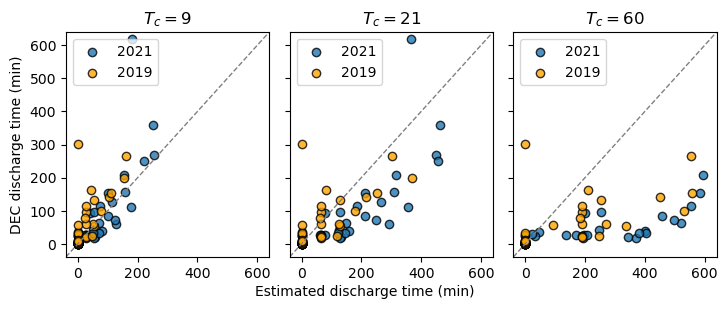

In [10]:
fig, axs = plt.subplots(ncols=3, figsize=(7.48, 3))
fig.subplots_adjust(left=0.1, right=0.97, top=0.9, bottom=0.15, hspace=0.4, wspace=0.1)
plot_discharge_scatter(6, axs[0], rain19, rain21)
plot_discharge_scatter(14, axs[1], rain19, rain21)
plot_discharge_scatter(40, axs[2], rain19, rain21)
axs[0].set_ylabel('DEC discharge time (min)')
axs[1].set_yticklabels([])
axs[2].set_yticklabels([])
axs[0].set_title('$T_c=9$')
axs[1].set_title('$T_c=21$') 
axs[2].set_title('$T_c=60$') 
fig.supxlabel('Estimated discharge time (min)', fontsize=10)